In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [5]:
df = pd.read_csv("../data/Impact of Lifestyle Factors on Student Productivity (Responses).csv")

In [7]:

# Set visual style
sns.set_theme(style="whitegrid")



target_col = 'Q31. How would you rate your overall academic productivity on a typical day?'
df = df.dropna(subset=[target_col])

# Map target to 3 classes
def map_target(val):
    if val in [1.0, 2.0]: return 'Decreased'
    elif val == 3.0: return 'No impact'
    elif val in [4.0, 5.0]: return 'Increased'
    return 'No impact'

df['Target'] = df[target_col].apply(map_target)

# 2. Feature Selection & Preprocessing
# Drop columns that are irrelevant to prediction (identifiers, text blobs, and the target itself)
cols_to_drop = [
    'Timestamp', 'Name', 'Score', target_col, 'Target',
    'Q35. Is there anything else you would like to share about how your lifestyle affects your productivity at NSTU? (Optional)'
]
X_raw = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Fill missing values and Encode categorical variables into numbers
X_encoded = pd.DataFrame()
le = LabelEncoder()

for col in X_raw.columns:
    # Fill missing values with the mode (most frequent value)
    mode_val = X_raw[col].mode()[0] if not X_raw[col].mode().empty else 'Missing'
    filled_col = X_raw[col].fillna(mode_val)
    # Convert text to numerical labels
    X_encoded[col] = le.fit_transform(filled_col.astype(str))

# Encode target
y = le.fit_transform(df['Target'])
target_names = le.classes_

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42, stratify=y)

# 4. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = rf_model.predict(X_test)
print("--- INSIGHT 1: Model Performance (Random Forest) ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))



--- INSIGHT 1: Model Performance (Random Forest) ---
Overall Accuracy: 59.38%

Classification Report:
              precision    recall  f1-score   support

   Decreased       0.57      0.57      0.57        14
   Increased       0.00      0.00      0.00         4
   No impact       0.61      0.79      0.69        14

    accuracy                           0.59        32
   macro avg       0.39      0.45      0.42        32
weighted avg       0.52      0.59      0.55        32



/home/mahmodul-hasan/Destop folder/3.1/Data Science and Analytics/My Data Science Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mahmodul-hasan/Destop folder/3.1/Data Science and Analytics/My Data Science Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mahmodul-hasan/Destop folder/3.1/Data Science and Analytics/My Data Science Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: P

/tmp/ipykernel_14507/2705939341.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=clean_feature_names, palette="viridis")


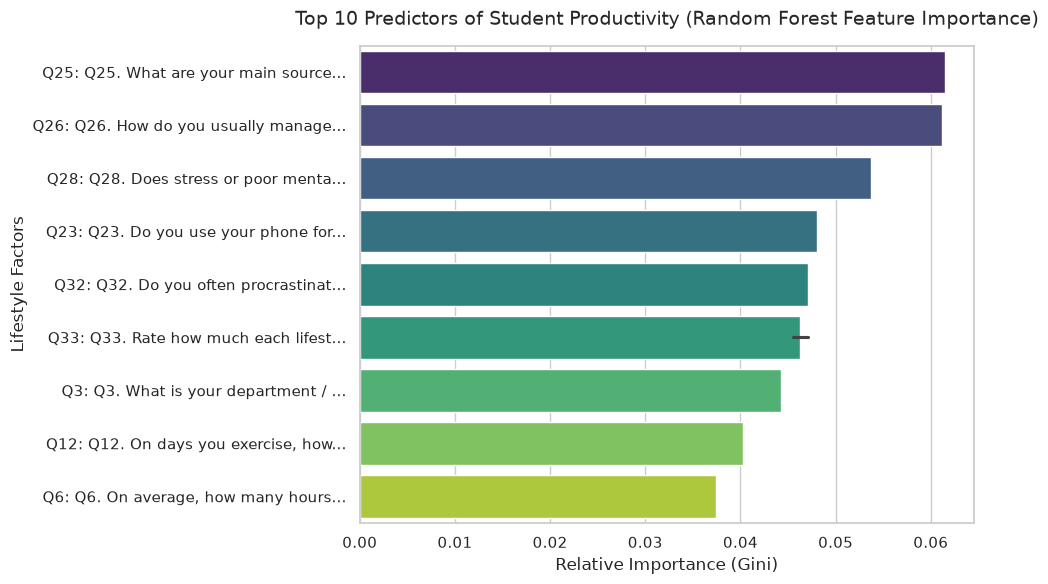

In [8]:
# ---------------------------------------------------------
# INSIGHT 2: Feature Importance Visualization
# ---------------------------------------------------------
# Get feature importances from the model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Take the top 10 most important features
top_n = 10
top_features = [X_encoded.columns[i] for i in indices[:top_n]]
top_importances = importances[indices][:top_n]

# Clean up long column names for the plot
clean_feature_names = [f.split('.')[0] + ": " + f.split('?')[0][:30] + "..." for f in top_features]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=clean_feature_names, palette="viridis")
plt.title('Top 10 Predictors of Student Productivity (Random Forest Feature Importance)', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Gini)', fontsize=12)
plt.ylabel('Lifestyle Factors', fontsize=12)
plt.tight_layout()
plt.show()



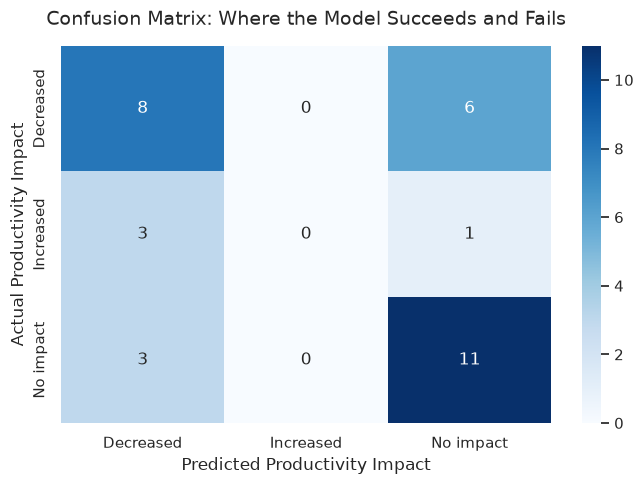

In [9]:
# ---------------------------------------------------------
# INSIGHT 3: Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Where the Model Succeeds and Fails', fontsize=14, pad=15)
plt.xlabel('Predicted Productivity Impact', fontsize=12)
plt.ylabel('Actual Productivity Impact', fontsize=12)
plt.tight_layout()
plt.show()